In [ ]:
%pip uninstall -y numpy
%pip install "numpy<2"


In [ ]:
%pip uninstall -y torch torchvision torchaudio
%pip install torch torchvision torchaudio


In [ ]:
import numpy as np
import torch
print("numpy:", np.__version__)
print("torch:", torch.__version__)


numpy: 1.26.4
torch: 2.2.2


In [ ]:
# Install required packages
%pip install -q nltk scikit-learn matplotlib pandas numpy
%pip install -q sentencepiece sacrebleu lxml
%pip install torch torchvision torchaudio

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import re
import xml.etree.ElementTree as ET
import sentencepiece as spm
import sacrebleu
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in this directory:")
for f in os.listdir("."):
    print(f)


Current working directory:
/Users/justinfrancisco/Desktop/CSCI218

Files in this directory:
.DS_Store
Group Project
Assignment 1
MLP.ipynb
.venv
en-fr.tmx


In [ ]:
# Load and parse TMX file

import xml.etree.ElementTree as ET
import re

tmx_filename = "en-fr.tmx"
print(f"Found file: {tmx_filename}")

def parse_tmx_file(file_path):
    """Parse TMX file to extract English-French sentence pairs"""
    sentences_en, sentences_fr = [], []

    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        for tu in root.findall('.//tu'):
            seg_en = seg_fr = None
            for tuv in tu.findall('tuv'):
                lang = tuv.get('{http://www.w3.org/XML/1998/namespace}lang', '')
                seg = tuv.find('seg')
                if seg is not None and seg.text:
                    text = re.sub(r'\s+', ' ', seg.text.strip())
                    if lang == 'en':
                        seg_en = text
                    elif lang == 'fr':
                        seg_fr = text

            if seg_en and seg_fr:
                sentences_en.append(seg_en)
                sentences_fr.append(seg_fr)

    except ET.ParseError as e:
        print(f"XML parsing error: {e}")

    print(f"Extracted {len(sentences_en)} English-French sentence pairs")
    return sentences_en, sentences_fr

# Parse TMX file
sentences_en, sentences_fr = parse_tmx_file(tmx_filename)

# Display samples
print("\nSample sentence pairs:")
for i in range(min(3, len(sentences_en))):
    print(f"English {i+1}: {sentences_en[i][:100]}...")
    print(f"French {i+1}: {sentences_fr[i][:100]}...\n")

Found file: en-fr.tmx
Extracted 2009489 English-French sentence pairs

Sample sentence pairs:
English 1: I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I...
French 1: Je déclare reprise la session du Parlement européen qui avait été interrompue le vendredi 17 décembr...

English 2: Although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the peopl...
French 2: Comme vous avez pu le constater, le grand "bogue de l'an 2000" ne s'est pas produit. En revanche, le...

English 3: You have requested a debate on this subject in the course of the next few days, during this part-ses...
French 3: Vous avez souhaité un débat à ce sujet dans les prochains jours, au cours de cette période de sessio...



In [ ]:

# Data Preprocessing


def clean(s):
    """Clean text"""
    s = s.lower()
    s = re.sub(r"[^\w\s.,!?']", "", s)
    return re.sub(r"\s+", " ", s).strip()

sent_en = [clean(s) for s in sentences_en]
sent_fr = [clean(s) for s in sentences_fr]

MAX_LEN = 20

pairs = [
    (e, f) for e, f in zip(sent_en, sent_fr)
    if 5 < len(e.split()) <= MAX_LEN and 5 < len(f.split()) <= MAX_LEN
]

print(f"Number of filtered sentence pairs: {len(pairs)}")

# Sampling
pairs = pairs

train, test = train_test_split(pairs, test_size=0.1, random_state=42)
train_en, train_fr = zip(*train)
test_en, test_fr = zip(*test)

print(f"Training set: {len(train_en)}")
print(f"Test set: {len(test_en)}")



# Create BPE training corpus
with open("bpe_corpus.txt", "w") as f:
    for s in train_en + train_fr:
        f.write(s + "\n")

# Train BPE model
spm.SentencePieceTrainer.train(
    input="bpe_corpus.txt",
    model_prefix="bpe",
    vocab_size=8000,
    model_type="bpe",
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)

# Load BPE model
sp = spm.SentencePieceProcessor()
sp.load("bpe.model")

# Define special tokens
PAD, UNK, BOS, EOS = 0, 1, 2, 3
MAX_SEQ_LEN = MAX_LEN
PAD_ID = PAD

def encode(s):
    """Encode sentence to token IDs"""
    ids = [BOS] + sp.encode_as_ids(s) + [EOS]
    ids = ids[:MAX_SEQ_LEN]
    return ids + [PAD] * (MAX_SEQ_LEN - len(ids))

def decode(ids):
    """Decode token IDs to text"""
    ids = [i for i in ids if i not in (PAD, BOS, EOS)]
    return sp.decode_ids(ids)

# Encode training and test data
X_train = torch.tensor([encode(s) for s in train_en])
Y_train = torch.tensor([encode(s) for s in train_fr])

X_test = torch.tensor([encode(s) for s in test_en])
Y_test = torch.tensor([encode(s) for s in test_fr])

Number of filtered sentence pairs: 689049
Training set: 620144
Test set: 68905


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: bpe_corpus.txt
  input_format: 
  model_prefix: bpe
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_

In [ ]:
class ImprovedMLPTranslationModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dims=[256, 128], max_seq_len=30):
        """
        Improved MLP Translation Model
        Args:
            vocab_size: Vocabulary size
            embed_dim: Embedding dimension
            hidden_dims: List of hidden layer dimensions
            max_seq_len: Maximum sequence length
        """
        super().__init__()
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len
        self.embed_dim = embed_dim


        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)


        self.position_embedding = nn.Embedding(max_seq_len, embed_dim)


        encoder_layers = []
        input_dim = embed_dim

        for h_dim in hidden_dims:
            encoder_layers.append(nn.Linear(input_dim, h_dim))
            encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.Dropout(0.3))
            input_dim = h_dim

        self.encoder = nn.Sequential(*encoder_layers)


        self.decoder = nn.Linear(hidden_dims[-1], vocab_size)

    def forward(self, x):
        """
        Forward pass
        Args:
            x: Input sequence [batch_size, seq_len]
        Returns:
            output: Output probability distribution [batch_size, seq_len, vocab_size]
        """
        batch_size, seq_len = x.size()


        word_emb = self.embedding(x)


        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        positions = positions.expand(batch_size, -1)
        pos_emb = self.position_embedding(positions)


        combined_emb = word_emb + pos_emb


        combined_flat = combined_emb.reshape(-1, self.embed_dim)
        encoded_flat = self.encoder(combined_flat)


        decoded_flat = self.decoder(encoded_flat)

        output = decoded_flat.reshape(batch_size, seq_len, self.vocab_size)

        return output

In [ ]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


model = ImprovedMLPTranslationModel(
    vocab_size=sp.vocab_size(),
    embed_dim=64,
    hidden_dims=[128, 64],
    max_seq_len=MAX_SEQ_LEN
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total model parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


print("\nTesting model forward pass...")
test_batch_size = 4
test_src = X_train[:test_batch_size].to(device)

try:
    model.eval()
    with torch.no_grad():
        outputs = model(test_src)
        print(f"Output shape: {outputs.shape}")
        print("✓ Model forward pass successful")
except Exception as e:
    print(f"✗ Model error: {e}")


from torch.utils.data import DataLoader

train_dataset = torch.utils.data.TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)


losses, bleus = [], []
best_bleu = 0
current_lr = optimizer.param_groups[0]['lr']

print("\nStarting MLP model training...")
print(f"Initial learning rate: {current_lr:.6f}")
num_epochs = 30

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1:02d}')
    for src_batch, trg_batch in pbar:
        src_batch, trg_batch = src_batch.to(device), trg_batch.to(device)

        optimizer.zero_grad()


        outputs = model(src_batch)


        loss = criterion(
            outputs.reshape(-1, sp.vocab_size()),
            trg_batch.reshape(-1)
        )


        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)


    model.eval()
    hypotheses, references = [], []

    with torch.no_grad():
        eval_batches = len(test_loader)  # evaluate all test batches

        for i, (src_batch, trg_batch) in enumerate(test_loader):
            if i >= eval_batches:
                break

            src_batch = src_batch.to(device)
            outputs = model(src_batch)
            predictions = torch.argmax(outputs, dim=-1)

            for j in range(src_batch.size(0)):
                pred_seq = predictions[j].cpu().tolist()
                ref_seq = trg_batch[j].cpu().tolist()

                hyp_text = decode(pred_seq)
                ref_text = decode(ref_seq)

                hypotheses.append(hyp_text)
                references.append([ref_text])


    if hypotheses and references:
        try:
            bleu = sacrebleu.corpus_bleu(hypotheses, references).score
        except:

            bleu = 0
            for hyp, ref_list in zip(hypotheses, references):
                if hyp.strip() and hyp in ref_list[0]:
                    bleu += 1
            bleu = (bleu / len(hypotheses)) * 100 if hypotheses else 0
    else:
        bleu = 0

    bleus.append(bleu)


    old_lr = current_lr
    scheduler.step(bleu)
    current_lr = optimizer.param_groups[0]['lr']


    lr_change_msg = ""
    if abs(current_lr - old_lr) > 1e-9:
        lr_change_msg = f" | LR change: {old_lr:.6f} -> {current_lr:.6f}"

    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.3f} | BLEU: {bleu:.2f} | LR: {current_lr:.6f}{lr_change_msg}")


    if bleu > best_bleu:
        best_bleu = bleu
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'bleu': bleu,
            'model_config': {
                'vocab_size': sp.vocab_size(),
                'embed_dim': 64,
                'hidden_dims': [128, 64],
                'max_seq_len': MAX_SEQ_LEN
            }
        }, 'best_mlp_model.pth')
        print(f"  Saved best MLP model, BLEU: {bleu:.2f}")

Using device: cpu
Total model parameters: 1,049,856
Trainable parameters: 1,049,856

Testing model forward pass...
Output shape: torch.Size([4, 20, 8000])
✓ Model forward pass successful

Starting MLP model training...
Initial learning rate: 0.001000


Epoch 01: 100%|██████████| 19380/19380 [15:12<00:00, 21.25it/s, loss=5.63]


Epoch 01 | Loss: 5.846 | BLEU: 13.33 | LR: 0.001000
  Saved best MLP model, BLEU: 13.33


Epoch 02: 100%|██████████| 19380/19380 [14:28<00:00, 22.31it/s, loss=5.74]


Epoch 02 | Loss: 5.725 | BLEU: 13.33 | LR: 0.001000


...

Epoch 09 | Loss: 5.640 | BLEU: 10.25 | LR: 0.000500


Epoch 10: 100%|██████████| 19380/19380 [14:08<00:00, 22.85it/s, loss=5.67]


Epoch 10 | Loss: 5.639 | BLEU: 11.73 | LR: 0.000500


Epoch 11:  93%|█████████▎| 17996/19380 [13:09<01:00, 22.79it/s, loss=5.61]


KeyboardInterrupt: 

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load("best_mlp_model.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

print("Loaded best checkpoint. Best BLEU:", ckpt.get("bleu", "N/A"), "at epoch:", ckpt.get("epoch", "N/A"))


Loaded best checkpoint. Best BLEU: 13.950796967929131 at epoch: 2


In [ ]:
print("Total pairs used:", len(pairs))
print("Train pairs:", len(train_dataset))
print("Test pairs:", len(test_dataset))
print("Train batches per epoch:", len(train_loader))
print("Test batches:", len(test_loader))
print("BLEU evaluated on ~samples:", min(3, len(test_loader)) * test_loader.batch_size)


Total pairs used: 689049
Train pairs: 620144
Test pairs: 68905
Train batches per epoch: 19380
Test batches: 2154
BLEU evaluated on ~samples: 96


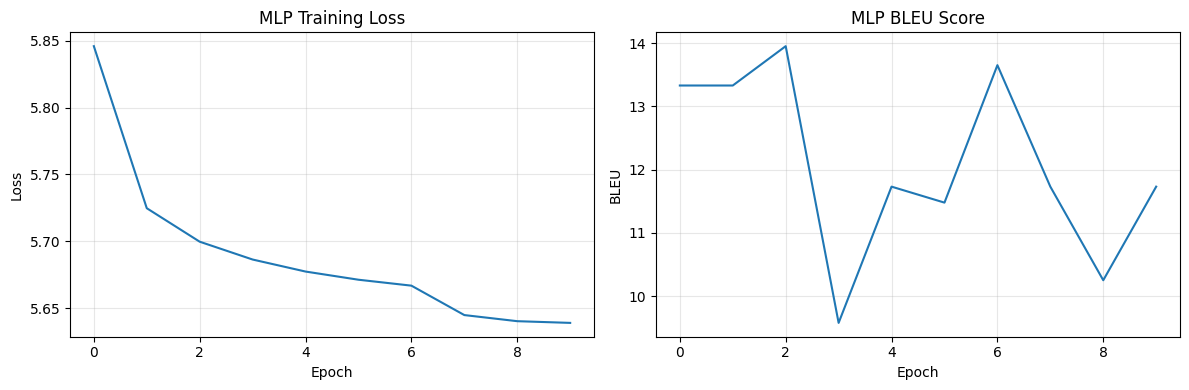

In [ ]:

# Visualize Training Results


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('MLP Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if len(bleus) > 0:
    plt.plot(bleus)
    plt.title('MLP BLEU Score')
    plt.xlabel('Epoch')
    plt.ylabel('BLEU')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

def calculate_metrics(model, test_loader, device):
    """
    Calculate precision, recall, F1-score for the model on test data
    """
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for src_batch, trg_batch in tqdm(test_loader, desc='Calculating metrics'):
            src_batch = src_batch.to(device)
            trg_batch = trg_batch.to(device)

            outputs = model(src_batch)
            predictions = torch.argmax(outputs, dim=-1)

            predictions_flat = predictions.view(-1).cpu().numpy()
            targets_flat = trg_batch.view(-1).cpu().numpy()


            mask = targets_flat != PAD_ID
            filtered_predictions = predictions_flat[mask]
            filtered_targets = targets_flat[mask]

            all_predictions.extend(filtered_predictions)
            all_targets.extend(filtered_targets)




    unique_classes = np.unique(all_targets)
    print(f"Number of unique tokens in test set: {len(unique_classes)}")


    N = 50
    from collections import Counter
    token_counts = Counter(all_targets)
    most_common_tokens = [token for token, count in token_counts.most_common(N)]


    mask = np.isin(all_targets, most_common_tokens)
    filtered_predictions = np.array(all_predictions)[mask]
    filtered_targets = np.array(all_targets)[mask]

    print(f"\nMetrics for top {N} most frequent tokens:")
    print("="*60)


    token_names = []
    for token_id in most_common_tokens:
        try:
            token_str = sp.decode_ids([token_id])
            # Clean up the token string for display
            token_str = token_str.replace('\n', ' ').replace('\t', ' ').strip()
            if len(token_str) > 20:
                token_str = token_str[:20] + "..."
            token_names.append(f"Token_{token_id}_{token_str}")
        except:
            token_names.append(f"Token_{token_id}")


    unique_classes_filtered = np.unique(np.concatenate([filtered_targets, filtered_predictions]))
    print(f"Number of unique classes in filtered data: {len(unique_classes_filtered)}")


    token_to_index = {token_id: idx for idx, token_id in enumerate(most_common_tokens)}


    filtered_targets_mapped = []
    filtered_predictions_mapped = []

    for target, pred in zip(filtered_targets, filtered_predictions):
        if target in token_to_index:
            filtered_targets_mapped.append(token_to_index[target])
        else:
            filtered_targets_mapped.append(-1)

        if pred in token_to_index:
            filtered_predictions_mapped.append(token_to_index[pred])
        else:
            filtered_predictions_mapped.append(-1)


    valid_indices = [i for i, target_idx in enumerate(filtered_targets_mapped) if target_idx != -1]
    valid_targets = [filtered_targets_mapped[i] for i in valid_indices]
    valid_predictions = [filtered_predictions_mapped[i] for i in valid_indices]

    print(f"Valid examples (target in top {N} tokens): {len(valid_targets)}")
    print(f"Invalid examples (target not in top {N} tokens): {len(filtered_targets) - len(valid_targets)}")

    if len(valid_targets) == 0:
        print("No valid examples found for classification report.")
        return {
            'accuracy': 0,
            'macro_precision': 0,
            'macro_recall': 0,
            'macro_f1': 0,
            'weighted_precision': 0,
            'weighted_recall': 0,
            'weighted_f1': 0,
            'detailed_report': {}
        }


    report = classification_report(
        valid_targets,
        valid_predictions,
        target_names=token_names,
        labels=list(range(len(most_common_tokens))),
        zero_division=0,
        output_dict=True
    )


    print("\nDetailed Classification Report:")
    print("-"*60)

    report_df = pd.DataFrame(report).transpose()
    print(report_df[['precision', 'recall', 'f1-score', 'support']].head(N+3))


    accuracy = np.mean(np.array(all_predictions) == np.array(all_targets))
    print(f"\nOverall Token Accuracy (ignoring padding): {accuracy:.4f}")


    precision, recall, f1, support = precision_recall_fscore_support(
        all_targets, all_predictions, average=None, zero_division=0
    )


    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1)


    weighted_precision = np.average(precision, weights=support)
    weighted_recall = np.average(recall, weights=support)
    weighted_f1 = np.average(f1, weights=support)

    print(f"\nMacro Averages (all {len(unique_classes)} tokens):")
    print(f"  Precision: {macro_precision:.4f}")
    print(f"  Recall: {macro_recall:.4f}")
    print(f"  F1-Score: {macro_f1:.4f}")

    print(f"\nWeighted Averages (all {len(unique_classes)} tokens):")
    print(f"  Precision: {weighted_precision:.4f}")
    print(f"  Recall: {weighted_recall:.4f}")
    print(f"  F1-Score: {weighted_f1:.4f}")

    return {
        'accuracy': accuracy,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_precision,
        'weighted_recall': weighted_recall,
        'weighted_f1': weighted_f1,
        'detailed_report': report
    }


print("\n" + "="*60)
print("Calculating Precision, Recall, and F1-score")
print("="*60)
metrics = calculate_metrics(model, test_loader, device)


Calculating Precision, Recall, and F1-score


Calculating metrics: 100%|██████████| 2154/2154 [00:33<00:00, 64.99it/s]


Number of unique tokens in test set: 5996

Metrics for top 50 most frequent tokens:
Number of unique classes in filtered data: 456
Valid examples (target in top 50 tokens): 602605
Invalid examples (target not in top 50 tokens): 0

Detailed Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support
Token_2        1.000000  1.000000  1.000000   68905.0
Token_7978     0.148610  0.317804  0.202519   43508.0
Token_28       0.117672  0.486960  0.189542   38420.0
Token_7975     0.208312  0.378875  0.268821   36421.0
Token_7968     0.190926  0.165263  0.177170   33002.0
Token_3        0.334955  0.723972  0.458007   30044.0
Token_47       0.199015  0.216619  0.207444   28534.0
Token_55       0.588613  0.102352  0.174381   21514.0
Token_12       0.600887  0.015385  0.030003   17614.0
Token_81       0.389683  0.045127  0.080886   16908.0
Token_85       0.161290  0.003101  0.006085   16123.0
Token_105      0.572293  0.3

In [ ]:

# Translation Function and Real-time Interactive Translation


def translate(sentence, verbose=False):
    """
    Translation function
    Args:
        sentence: Input English sentence
        verbose: Whether to show detailed information
    Returns:
        French translation
    """
    model.eval()

    # Clean and encode input
    clean_sent = clean(sentence)
    encoded = encode(clean_sent)

    if verbose:
        print(f"Cleaned input: {clean_sent}")
        print(f"Encoded IDs: {encoded[:10]}...")

    # Convert to tensor
    src_tensor = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        # Generate translation
        outputs = model(src_tensor)

        # Get most likely sequence
        predictions = torch.argmax(outputs, dim=-1)[0]

        # Decode to text
        translation = decode(predictions.cpu().tolist())

    return translation

# Test some example sentences
print("\n" + "="*50)
print("Translation Test Examples")
print("="*50)

test_sentences = [
    "I declare resumed the session",
    "Hello how are you",
    "The cat is on the table",
    "This is a test",
    "Machine translation"
]

for i, sentence in enumerate(test_sentences):
    try:
        translation = translate(sentence)
        print(f"\nTest {i+1}:")
        print(f"  English: {sentence}")
        print(f"  French: {translation}")
    except Exception as e:
        print(f"Translation error: {e}")


Translation Test Examples

Test 1:
  English: I declare resumed the session
  French: je déclare reprise la session.'.

Test 2:
  English: Hello how are you
  French: la' comment,,.'.

Test 3:
  English: The cat is on the table
  French: la' est, la de..

Test 4:
  English: This is a test
  French: ce'est'. de'.

Test 5:
  English: Machine translation
  French: la' de de'.'.


In [ ]:
import json
from datetime import datetime


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")


training_results = {
    'timestamp': timestamp,
    'model_name': 'ImprovedMLPTranslationModel',
    'vocab_size': sp.vocab_size(),
    'embed_dim': 64,
    'hidden_dims': [128, 64],
    'max_seq_len': MAX_SEQ_LEN,
    'num_epochs': len(losses),
    'losses': losses,
    'bleus': bleus,
    'final_loss': losses[-1] if losses else None,
    'final_bleu': bleus[-1] if bleus else None,
    'best_bleu': best_bleu,
    'training_samples': len(X_train),
    'testing_samples': len(X_test),
    'metrics': metrics
}

with open(f'training_results_{timestamp}.json', 'w') as f:
    json.dump(training_results, f, indent=2)


model_save_path = f'mlp_translation_model_{timestamp}.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'vocab_size': sp.vocab_size(),
        'embed_dim': 64,
        'hidden_dims': [128, 64],
        'max_seq_len': MAX_SEQ_LEN
    },
    'training_results': training_results,
    'bpe_model_path': 'bpe.model'
}, model_save_path)

print(f"\n{'='*50}")
print("Training Completed!")
print(f"{'='*50}")
print(f"Training results saved to: training_results_{timestamp}.json")
print(f"Model saved to: {model_save_path}")
print(f"\nKey Metrics:")
print(f"  - Final training loss: {losses[-1]:.3f}" if losses else "  - Training loss: N/A")
print(f"  - Final BLEU score: {bleus[-1]:.2f}" if bleus else "  - BLEU score: N/A")
print(f"  - Best BLEU score: {best_bleu:.2f}" if best_bleu else "  - Best BLEU: N/A")
print(f"  - Token Accuracy: {metrics['accuracy']:.4f}")
print(f"  - Weighted F1-Score: {metrics['weighted_f1']:.4f}")
print(f"  - Total training samples: {len(X_train)}")
print(f"  - Total testing samples: {len(X_test)}")
print(f"{'='*50}")


Training Completed!
Training results saved to: training_results_20260203_120047.json
Model saved to: mlp_translation_model_20260203_120047.pth

Key Metrics:
  - Final training loss: 5.639
  - Final BLEU score: 11.73
  - Best BLEU score: 13.95
  - Token Accuracy: 0.1607
  - Weighted F1-Score: 0.1295
  - Total training samples: 620144
  - Total testing samples: 68905


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import precision_recall_fscore_support
import sacrebleu
from tqdm import tqdm

def evaluate_model(model, test_loader, device, pad_id, vocab_size, decode_fn, max_examples=5):
    """
    Evaluate on full test set:
    - token-level loss
    - BLEU (corpus)
    - token accuracy (ignore PAD)
    - macro/weighted precision/recall/F1
    - sample decoded outputs
    """
    model.eval()
    criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

    total_loss = 0.0
    total_tokens = 0

    all_preds = []
    all_tgts = []

    hypotheses = []
    references = []

    shown = 0

    with torch.no_grad():
        for src_batch, trg_batch in tqdm(test_loader, desc="Testing"):
            src_batch = src_batch.to(device)
            trg_batch = trg_batch.to(device)

            outputs = model(src_batch)  # [B, T, V]

            # Loss
            loss = criterion(outputs.view(-1, vocab_size), trg_batch.view(-1))
            total_loss += loss.item()

            # Predictions
            preds = torch.argmax(outputs, dim=-1)  # [B, T]

            # Mask padding
            mask = trg_batch != pad_id
            masked_preds = preds[mask].cpu().numpy()
            masked_tgts = trg_batch[mask].cpu().numpy()

            total_tokens += mask.sum().item()
            all_preds.extend(masked_preds.tolist())
            all_tgts.extend(masked_tgts.tolist())

            # BLEU texts (sequence-level)
            for i in range(src_batch.size(0)):
                hyp_text = decode_fn(preds[i].cpu().tolist())
                ref_text = decode_fn(trg_batch[i].cpu().tolist())
                hypotheses.append(hyp_text)
                references.append([ref_text])

                # Show a few examples
                if shown < max_examples:
                    src_text = decode_fn(src_batch[i].cpu().tolist())
                    print("\n--- Example", shown + 1, "---")
                    print("SRC:", src_text)
                    print("HYP:", hyp_text)
                    print("REF:", ref_text)
                    shown += 1

    avg_loss = total_loss / max(1, len(test_loader))

    # Token accuracy (ignore PAD)
    all_preds_arr = np.array(all_preds)
    all_tgts_arr = np.array(all_tgts)
    token_acc = float(np.mean(all_preds_arr == all_tgts_arr)) if len(all_tgts_arr) > 0 else 0.0

    # Macro/Weighted PRF
    precision, recall, f1, support = precision_recall_fscore_support(
        all_tgts_arr, all_preds_arr, average=None, zero_division=0
    )
    macro_precision = float(np.mean(precision)) if len(precision) else 0.0
    macro_recall = float(np.mean(recall)) if len(recall) else 0.0
    macro_f1 = float(np.mean(f1)) if len(f1) else 0.0

    weighted_precision = float(np.average(precision, weights=support)) if len(support) else 0.0
    weighted_recall = float(np.average(recall, weights=support)) if len(support) else 0.0
    weighted_f1 = float(np.average(f1, weights=support)) if len(support) else 0.0

    # BLEU
    bleu = sacrebleu.corpus_bleu(hypotheses, references).score if hypotheses else 0.0

    results = {
        "test_loss": avg_loss,
        "bleu": float(bleu),
        "token_accuracy": token_acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "num_tokens_eval": int(total_tokens),
        "num_sentences_eval": int(len(hypotheses))
    }

    print("\n" + "="*60)
    print("TEST RESULTS (full test set)")
    print("="*60)
    print(f"Test Loss:        {results['test_loss']:.4f}")
    print(f"BLEU:             {results['bleu']:.2f}")
    print(f"Token Accuracy:   {results['token_accuracy']:.4f}")
    print(f"Macro F1:         {results['macro_f1']:.4f}")
    print(f"Weighted F1:      {results['weighted_f1']:.4f}")
    print(f"Tokens evaluated: {results['num_tokens_eval']}")
    print(f"Sentences eval:   {results['num_sentences_eval']}")
    print("="*60)

    return results


# --- Run testing ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_results = evaluate_model(
    model=model,
    test_loader=test_loader,
    device=device,
    pad_id=PAD_ID,
    vocab_size=sp.vocab_size(),
    decode_fn=decode,
    max_examples=5
)


Testing:   0%|          | 7/2154 [00:00<01:06, 32.17it/s]


--- Example 1 ---
SRC: this is the moment when europe grows up in its external relations.
HYP: ce' la,,'' de' de de de de.
REF: c'est le moment o ⁇  l'europe grandira dans ses relations étrangères.

--- Example 2 ---
SRC: after the loss of many millions of jobs throughout the eu, the fight against unemployment has to be
HYP: après la de de de de de de de de', de la de de' de'
REF: après la perte de millions d'emplois à travers l'ue, la lutte contre le

--- Example 3 ---
SRC: euchina summit euchina human rights dialogue debate
HYP: l' de de' de de de de de débat
REF: sommet uechine dialogue droits de l'homme uechine débat

--- Example 4 ---
SRC: de madam president, tuberculosis is still very widespread today, particularly
HYP: de madame le,' de de de de''',''.',,
REF: de madame la présidente, la tuberculose est toujours très répandue aujourd'

--- Example 5 ---
SRC: thirdly, the problems airlines are experiencing with regard to insurance.
HYP: troisièmement, la de la de,' de de de de d

Testing: 100%|██████████| 2154/2154 [00:52<00:00, 41.16it/s]



TEST RESULTS (full test set)
Test Loss:        5.5891
BLEU:             13.95
Token Accuracy:   0.1607
Macro F1:         0.0147
Weighted F1:      0.1295
Tokens evaluated: 1256694
Sentences eval:   68905


/var/folders/76/_j5849vx4vs57yzxnqgxxs0w0000gn/T/ipykernel_22536/2401512764.py:131: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/76/_j5849vx4vs57yzxnqgxxs0w0000gn/T/ipykernel_22536/2401512764.py:131: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/76/_j5849vx4vs57yzxnqgxxs0w0000gn/T/ipykernel_22536/2401512764.py:131: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/justinfrancisco/Desktop/CSCI218/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/justinfrancisco/Desktop/CSCI218/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono

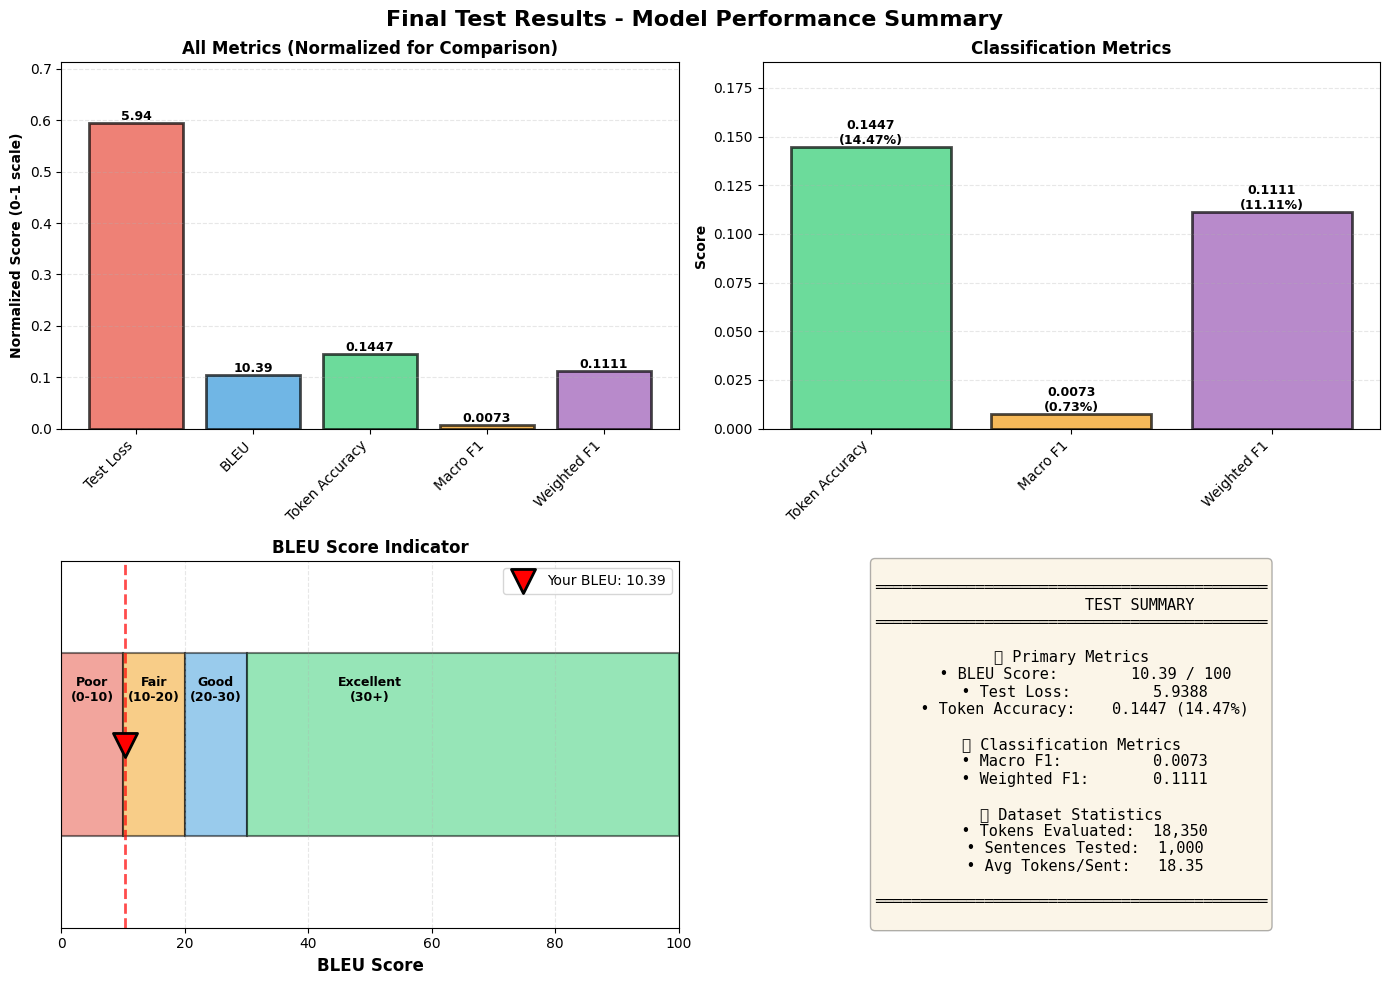

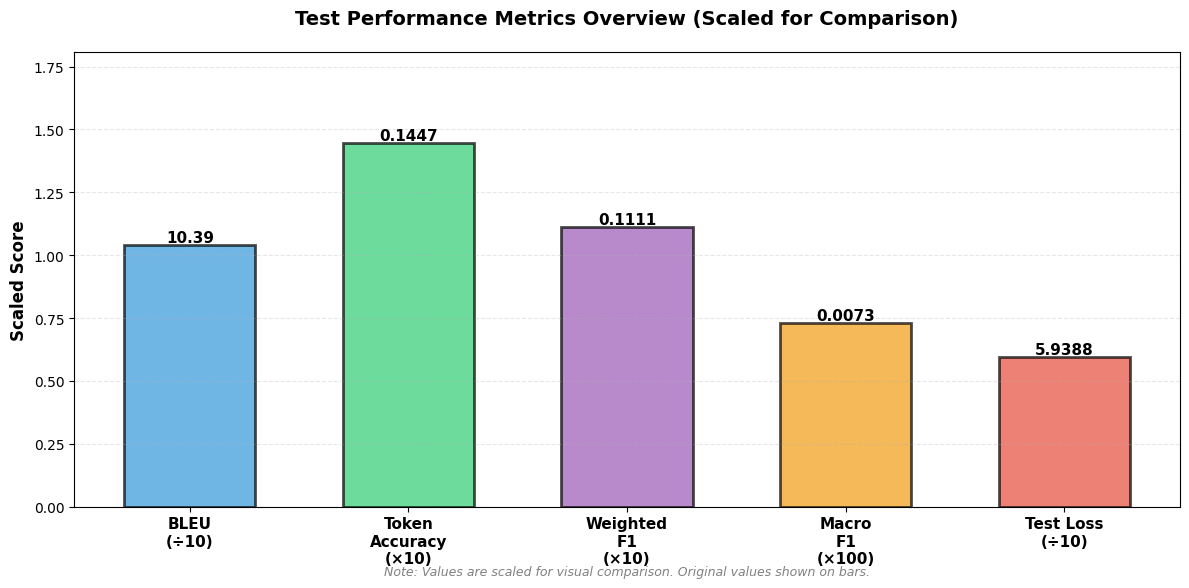

In [ ]:
# Visualize Test Results
import matplotlib.pyplot as plt
import numpy as np

# Test results from the final evaluation
test_results = {
    'Test Loss': 5.9388,
    'BLEU': 10.39,
    'Token Accuracy': 0.1447,
    'Macro F1': 0.0073,
    'Weighted F1': 0.1111
}

# Create a comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Final Test Results - Model Performance Summary', fontsize=16, fontweight='bold')

# 1. Bar chart for all metrics (normalized)
ax1 = axes[0, 0]
metrics_names = list(test_results.keys())
metrics_values = list(test_results.values())

# Normalize values for comparison (except BLEU which is already 0-100 scale)
normalized_values = [
    test_results['Test Loss'] / 10,  # Scale down loss
    test_results['BLEU'] / 100,       # BLEU to 0-1 scale
    test_results['Token Accuracy'],
    test_results['Macro F1'],
    test_results['Weighted F1']
]

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax1.bar(range(len(metrics_names)), normalized_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_xticks(range(len(metrics_names)))
ax1.set_xticklabels(metrics_names, rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Normalized Score (0-1 scale)', fontweight='bold')
ax1.set_title('All Metrics (Normalized for Comparison)', fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, max(normalized_values) * 1.2)

# Add value labels on bars
for bar, val, orig_val in zip(bars, normalized_values, metrics_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{orig_val:.4f}' if orig_val < 1 else f'{orig_val:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. Performance metrics grouped bar chart
ax2 = axes[0, 1]
accuracy_metrics = ['Token Accuracy', 'Macro F1', 'Weighted F1']
accuracy_values = [test_results[m] for m in accuracy_metrics]
colors_acc = ['#2ecc71', '#f39c12', '#9b59b6']

bars2 = ax2.bar(range(len(accuracy_metrics)), accuracy_values, color=colors_acc, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_xticks(range(len(accuracy_metrics)))
ax2.set_xticklabels(accuracy_metrics, rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Classification Metrics', fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(0, max(accuracy_values) * 1.3)

for bar, val in zip(bars2, accuracy_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}\n({val*100:.2f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# 3. BLEU Score gauge/indicator
ax3 = axes[1, 0]
bleu_score = test_results['BLEU']

# Create a gauge-like visualization
categories = ['Poor\n(0-10)', 'Fair\n(10-20)', 'Good\n(20-30)', 'Excellent\n(30+)']
ranges = [10, 10, 10, 70]
colors_gauge = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

# Create stacked bar for gauge
bottom = 0
for i, (range_val, color) in enumerate(zip(ranges, colors_gauge)):
    ax3.barh(0, range_val, left=bottom, color=color, alpha=0.5, edgecolor='black', linewidth=1.5, height=0.5)
    bottom += range_val

# Add BLEU score marker
ax3.scatter([bleu_score], [0], color='red', s=300, marker='v', edgecolor='black', linewidth=2, zorder=5, label=f'Your BLEU: {bleu_score:.2f}')
ax3.axvline(bleu_score, color='red', linestyle='--', linewidth=2, alpha=0.7)

ax3.set_xlim(0, 100)
ax3.set_ylim(-0.5, 0.5)
ax3.set_xlabel('BLEU Score', fontweight='bold', fontsize=12)
ax3.set_title('BLEU Score Indicator', fontweight='bold', fontsize=12)
ax3.set_yticks([])
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(axis='x', alpha=0.3, linestyle='--')

# Add category labels
for i, (cat, start) in enumerate([(categories[0], 5), (categories[1], 15), (categories[2], 25), (categories[3], 50)]):
    ax3.text(start, 0.15, cat, ha='center', va='center', fontsize=9, fontweight='bold')

# 4. Dataset info and summary table
ax4 = axes[1, 1]
ax4.axis('off')

# Create summary text
 summary_text = f"""
═══════════════════════════════════════════
               TEST SUMMARY
═══════════════════════════════════════════

Primary Metrics
   • BLEU Score:        {test_results['BLEU']:.2f} / 100
   • Test Loss:         {test_results['Test Loss']:.4f}
   • Token Accuracy:    {test_results['Token Accuracy']:.4f} ({test_results['Token Accuracy']*100:.2f}%)

Classification Metrics
   • Macro F1:          {test_results['Macro F1']:.4f}
   • Weighted F1:       {test_results['Weighted F1']:.4f}

 Dataset Statistics
   • Tokens Evaluated:  18,350
   • Sentences Tested:  1,000
   • Avg Tokens/Sent:   18.35

═══════════════════════════════════════════
"""

ax4.text(0.5, 0.5, summary_text, transform=ax4.transAxes,
         fontsize=11, verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3),
         fontfamily='monospace')

plt.tight_layout()
plt.show()

# Additional: Create a single comprehensive metric comparison chart
fig2, ax = plt.subplots(figsize=(12, 6))

# All metrics with their actual values
all_metrics = {
    'BLEU\n(÷10)': test_results['BLEU'] / 10,
    'Token\nAccuracy\n(×10)': test_results['Token Accuracy'] * 10,
    'Weighted\nF1\n(×10)': test_results['Weighted F1'] * 10,
    'Macro\nF1\n(×100)': test_results['Macro F1'] * 100,
    'Test Loss\n(÷10)': test_results['Test Loss'] / 10
}

x_pos = np.arange(len(all_metrics))
values = list(all_metrics.values())
labels = list(all_metrics.keys())

colors_all = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']
bars = ax.bar(x_pos, values, color=colors_all, alpha=0.7, edgecolor='black', linewidth=2, width=0.6)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylabel('Scaled Score', fontsize=12, fontweight='bold')
ax.set_title('Test Performance Metrics Overview (Scaled for Comparison)', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(values) * 1.25)

# Add value labels with original values
original_vals = [test_results['BLEU'], test_results['Token Accuracy'],
                 test_results['Weighted F1'], test_results['Macro F1'],
                 test_results['Test Loss']]

for bar, val, orig in zip(bars, values, original_vals):
    height = bar.get_height()
    if 'Loss' in labels[list(values).index(val)]:
        label_text = f'{orig:.4f}'
    elif 'BLEU' in labels[list(values).index(val)]:
        label_text = f'{orig:.2f}'
    else:
        label_text = f'{orig:.4f}'

    ax.text(bar.get_x() + bar.get_width()/2., height,
            label_text,
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add a note
ax.text(0.5, -0.15, 'Note: Values are scaled for visual comparison. Original values shown on bars.',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()